<a href="https://colab.research.google.com/github/Dynamic1610/COVID-Trends-Tracker/blob/main/churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Retention & Churn Analysis
**Data Science & Analytics Internship — Task 2**

## Step 1: Upload the dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


## Step 2: Load & clean
The raw file has one known issue: `TotalCharges` is stored as text, and 11 brand-new customers (tenure = 0) have it blank because they haven't been billed yet.

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("Missing values before cleaning:\n", df.isnull().sum().sum())

# TotalCharges is text with some blanks -> convert, then fix
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("\nRows with blank TotalCharges:", df['TotalCharges'].isnull().sum())
print(df[df['TotalCharges'].isnull()][['customerID','tenure','MonthlyCharges']])

Shape: (7043, 21)
Missing values before cleaning:
 0

Rows with blank TotalCharges: 11
      customerID  tenure  MonthlyCharges
488   4472-LVYGI       0           52.55
753   3115-CZMZD       0           20.25
936   5709-LVOEQ       0           80.85
1082  4367-NUYAO       0           25.75
1340  1371-DWPAZ       0           56.05
3331  7644-OMVMY       0           19.85
3826  3213-VVOLG       0           25.35
4380  2520-SGTTA       0           20.00
5218  2923-ARZLG       0           19.70
6670  4075-WKNIU       0           73.35
6754  2775-SEFEE       0           61.90


In [ ]:
# These are all tenure=0 customers -- they haven't been billed a full cycle yet.
# Fill with their MonthlyCharges (their charges-to-date) rather than dropping them --
# dropping would quietly remove real "brand new customer" signal from the tenure=0 cohort.
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

df['ChurnFlag'] = (df['Churn'] == 'Yes').astype(int)

print("Missing values after cleaning:", df.isnull().sum().sum())
print("Duplicate customer IDs:", df['customerID'].duplicated().sum())
print(f"\n{len(df):,} customers, {df['ChurnFlag'].sum():,} churned ({df['ChurnFlag'].mean()*100:.1f}%)")
df.head()

Missing values after cleaning: 0
Duplicate customer IDs: 0

7,043 customers, 1,869 churned (26.5%)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## Step 3: Top-line KPIs

In [ ]:
total_customers = len(df)
churned = df['ChurnFlag'].sum()
churn_rate = df['ChurnFlag'].mean() * 100
avg_tenure = df['tenure'].mean()
revenue_at_risk = df[df['Churn']=='Yes']['MonthlyCharges'].sum()
pct_revenue_at_risk = revenue_at_risk / df['MonthlyCharges'].sum() * 100

print(f"Total customers:          {total_customers:,}")
print(f"Churned:                  {churned:,}")
print(f"Churn rate:               {churn_rate:.1f}%")
print(f"Average tenure:           {avg_tenure:.1f} months")
print(f"Monthly revenue at risk:  ${revenue_at_risk:,.0f}  ({pct_revenue_at_risk:.1f}% of total)")

Total customers:          7,043
Churned:                  1,869
Churn rate:               26.5%
Average tenure:           32.4 months
Monthly revenue at risk:  $139,131  (30.5% of total)


## Step 4: Churn by contract type
This is the single strongest driver in the dataset.

In [ ]:
def churn_by(col):
    g = df.groupby(col, observed=True)['ChurnFlag'].agg(['mean','count'])
    g['mean'] = (g['mean']*100).round(1)
    return g.rename(columns={'mean':'Churn %','count':'Customers'}).sort_values('Churn %', ascending=False)

churn_by('Contract')

,Churn %,Customers
Contract,,
Month-to-month,42.7,3875
One year,11.3,1473
Two year,2.8,1695


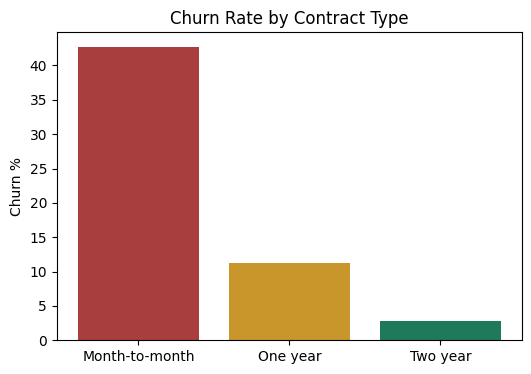

In [ ]:
import matplotlib.pyplot as plt

cbc = churn_by('Contract')
plt.figure(figsize=(6,4))
plt.bar(cbc.index, cbc['Churn %'], color=['#A83E3E','#C9962B','#1F7A5C'])
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn %')
plt.show()

**Finding:** Month-to-month customers churn at 42.7% vs. just 2.8% for two-year contracts. Contract length is the biggest lever the business has.

## Step 5: Other churn drivers
Internet service, payment method, and whether the customer has support add-ons.

In [ ]:
print("=== By Internet Service ===")
print(churn_by('InternetService'))
print()
print("=== By Payment Method ===")
print(churn_by('PaymentMethod'))
print()
print("=== By Online Security ===")
print(churn_by('OnlineSecurity'))
print()
print("=== By Tech Support ===")
print(churn_by('TechSupport'))
print()
print("=== By Senior Citizen ===")
print(churn_by('SeniorCitizen'))

=== By Internet Service ===
                 Churn %  Customers
InternetService                    
Fiber optic         41.9       3096
DSL                 19.0       2421
No                   7.4       1526

=== By Payment Method ===
                           Churn %  Customers
PaymentMethod                                
Electronic check              45.3       2365
Mailed check                  19.1       1612
Bank transfer (automatic)     16.7       1544
Credit card (automatic)       15.2       1522

=== By Online Security ===
                     Churn %  Customers
OnlineSecurity                         
No                      41.8       3498
Yes                     14.6       2019
No internet service      7.4       1526

=== By Tech Support ===
                     Churn %  Customers
TechSupport                            
No                      41.6       3473
Yes                     15.2       2044
No internet service      7.4       1526

=== By Senior Citizen ===
         

**Findings:** Fiber optic customers churn more than DSL (41.9% vs 19.0%) despite fiber being the premium product. Electronic check payers churn at 45.3% — far above any other payment method. Customers without Online Security or Tech Support churn roughly 3x more than those with it.

## Step 6: Tenure cohorts — the retention curve
Grouping customers by how long they've been active shows exactly when the business loses people.

In [ ]:
df['TenureGroup'] = pd.cut(df['tenure'], bins=[-1,12,24,36,48,60,72],
    labels=['0-12 mo','13-24 mo','25-36 mo','37-48 mo','49-60 mo','61-72 mo'])

tenure_churn = churn_by('TenureGroup')
tenure_churn

,Churn %,Customers
TenureGroup,,
0-12 mo,47.4,2186
13-24 mo,28.7,1024
25-36 mo,21.6,832
37-48 mo,19.0,762
49-60 mo,14.4,832
61-72 mo,6.6,1407


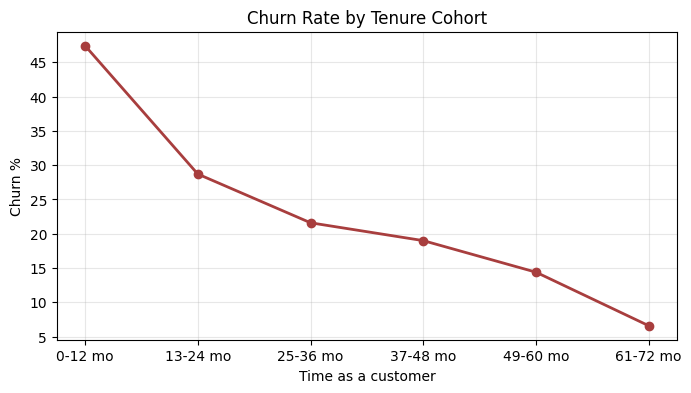

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(tenure_churn.index.astype(str), tenure_churn['Churn %'], marker='o', color='#A83E3E', linewidth=2)
plt.title('Churn Rate by Tenure Cohort')
plt.ylabel('Churn %')
plt.xlabel('Time as a customer')
plt.grid(alpha=0.3)
plt.show()

**Finding:** churn risk drops sharply the longer a customer stays — 47.4% in the first year vs. 6.6% after five years. If a customer survives their first 12 months, they're dramatically more likely to stay long-term. Retention efforts should concentrate on the first year.

## Step 7: The highest-risk customer segment
Combining the three strongest individual drivers finds the segment the business should prioritize.

In [ ]:
high_risk = df[(df['Contract']=='Month-to-month') &
               (df['InternetService']=='Fiber optic') &
               (df['PaymentMethod']=='Electronic check')]

low_risk = df[(df['Contract']=='Two year') &
              (df['OnlineSecurity']=='Yes') &
              (df['TechSupport']=='Yes')]

print(f"HIGH-RISK segment (month-to-month + fiber + electronic check):")
print(f"  {len(high_risk):,} customers ({len(high_risk)/len(df)*100:.1f}% of customer base)")
print(f"  Churn rate: {high_risk['ChurnFlag'].mean()*100:.1f}%")
print()
print(f"LOW-RISK segment (two-year + online security + tech support):")
print(f"  {len(low_risk):,} customers")
print(f"  Churn rate: {low_risk['ChurnFlag'].mean()*100:.1f}%")

HIGH-RISK segment (month-to-month + fiber + electronic check):
  1,307 customers (18.6% of customer base)
  Churn rate: 60.4%

LOW-RISK segment (two-year + online security + tech support):
  600 customers
  Churn rate: 3.0%


**Finding:** the high-risk segment is 18.5% of the entire customer base and churns at 60.4% — more than double the overall rate. The low-risk segment, by contrast, churns at just 3.0%. This is the clearest targeting opportunity in the dataset.

## Step 8: Monthly charges — do churned customers pay more?

        count   mean    std    min    25%    50%   75%     max
Churn                                                         
No     5174.0  61.27  31.09  18.25  25.10  64.43  88.4  118.75
Yes    1869.0  74.44  24.67  18.85  56.15  79.65  94.2  118.35


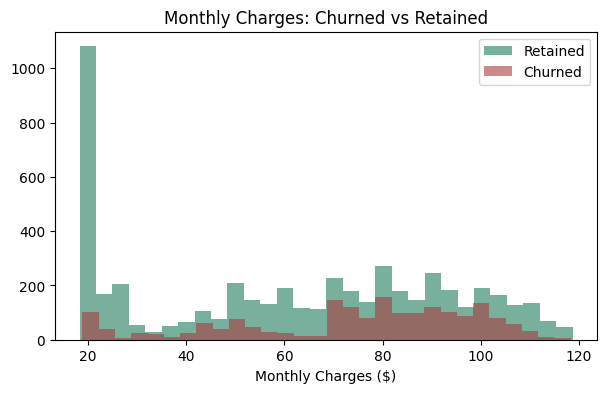

In [ ]:
print(df.groupby('Churn')['MonthlyCharges'].describe().round(2))

plt.figure(figsize=(7,4))
plt.hist(df[df['Churn']=='No']['MonthlyCharges'], bins=30, alpha=0.6, label='Retained', color='#1F7A5C')
plt.hist(df[df['Churn']=='Yes']['MonthlyCharges'], bins=30, alpha=0.6, label='Churned', color='#A83E3E')
plt.title('Monthly Charges: Churned vs Retained')
plt.xlabel('Monthly Charges ($)')
plt.legend()
plt.show()

**Finding:** churned customers pay $74.44/month on average vs. $61.27 for retained customers. Combined with the fiber-optic finding above, this points to price sensitivity concentrated in the premium tier.

## Step 9: Summary of recommendations

1. **Push month-to-month customers toward annual contracts** — offer a discount or incentive to convert; this single change has the largest churn-reduction potential in the data (42.7% → 2.8-11.3%).
2. **Investigate fiber-optic pricing and service quality** — fiber customers pay the most and churn the most, which shouldn't be true of a premium product. Worth a direct pricing/competitor review.
3. **Nudge Electronic Check payers to autopay** — a small incentive to switch to automatic bank/card payment could meaningfully cut churn in that group (45.3% vs 15-19%).
4. **Bundle Online Security + Tech Support into onboarding** — customers with these add-ons churn 3x less; offering them free for the first 3 months could reduce early-tenure churn specifically.
5. **Prioritize retention spend on the first 12 months** — this is where churn risk is highest by far; a structured onboarding/check-in program matters most here, not later in the relationship.

See `README.md` for the full write-up and `churn_dashboard.html` for the interactive version of every chart above.